In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/beyzanurnl/pngrfm/rfmkopyas.png
/kaggle/input/datasets/beyzanurnl/flo-data-20k/flo_data_20k.csv


# 📊 From RFM to Revenue: FLO Customer Segmentation


[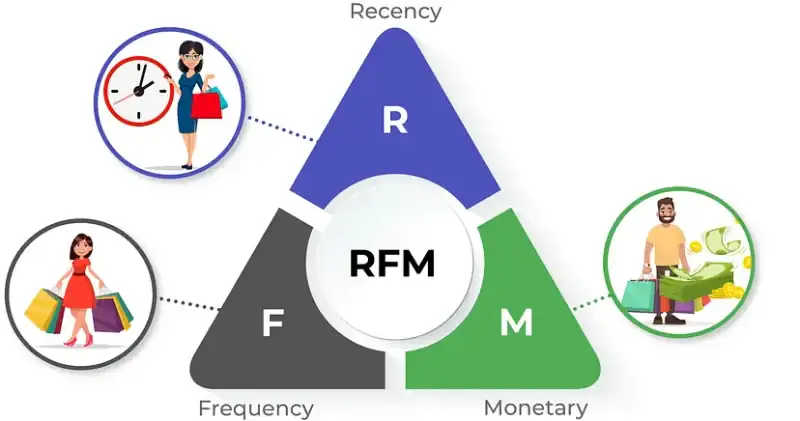](http://)

## Project Overview

Understanding customer behavior is essential for sustainable growth in retail.  
In this project, we apply **RFM (Recency, Frequency, Monetary)** analysis to segment FLO customers and transform transactional data into actionable business insights.

🎯 **Goal:** Identify high-value, loyal, and at-risk customers to enable data-driven marketing strategies.

---
## Business Problem

FLO aims to segment its customers based on purchasing behavior in order to:

- Identify high-value and loyal customers  
- Detect customers at risk of churn  
- Develop targeted marketing strategies  

**Expected Impact**

- Increased customer retention  
- Higher customer lifetime value  
- More efficient marketing spend  

---

## Dataset Overview

The dataset contains **20,000 FLO customers** who made purchases between **2020–2021** across both online and offline channels.

### Key Variables

| Column | Description |
|------|-------------|
| order_channel | Platform used for purchase (Android, iOS, Desktop, Mobile, Offline) |
| last_order_channel | Platform used in the last purchase |
| first_order_date | First purchase date |
| last_order_date | Last purchase date |
| last_order_date_online | Last online purchase date |
| last_order_date_offline | Last offline purchase date |
| order_num_total_ever_online | Total online purchases |
| order_num_total_ever_offline | Total offline purchases |
| customer_value_total_ever_offline | Total spent offline |
| customer_value_total_ever_online | Total spent online |
| interested_in_categories_12 | Categories purchased in the last 12 months |

In [2]:
# ============================================================
# Setup: Imports & Display Settings
# ============================================================

# Standard library
import datetime as dt
import warnings

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

# Display
from IPython.display import display

# Suppress warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Visual style
sns.set(style="whitegrid")

In [3]:
# ============================================================
# Load Data
# ============================================================

df_ = pd.read_csv("/kaggle/input/datasets/beyzanurnl/flo-data-20k/flo_data_20k.csv")
df = df_.copy()
df.head()

,master_id,order_channel,last_order_channel,first_order_date,last_order_date,last_order_date_online,last_order_date_offline,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,customer_value_total_ever_online,interested_in_categories_12
0,cc294636-19f0-11eb-8d74-000d3a38a36f,Android App,Offline,2020-10-30,2021-02-26,2021-02-21,2021-02-26,4.00,1.00,139.99,799.38,[KADIN]
1,f431bd5a-ab7b-11e9-a2fc-000d3a38a36f,Android App,Mobile,2017-02-08,2021-02-16,2021-02-16,2020-01-10,19.00,2.00,159.97,"1,853.58","[ERKEK, COCUK, KADIN, AKTIFSPOR]"
2,69b69676-1a40-11ea-941b-000d3a38a36f,Android App,Android App,2019-11-27,2020-11-27,2020-11-27,2019-12-01,3.00,2.00,189.97,395.35,"[ERKEK, KADIN]"
3,1854e56c-491f-11eb-806e-000d3a38a36f,Android App,Android App,2021-01-06,2021-01-17,2021-01-17,2021-01-06,1.00,1.00,39.99,81.98,"[AKTIFCOCUK, COCUK]"
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,Desktop,Desktop,2019-08-03,2021-03-07,2021-03-07,2019-08-03,1.00,1.00,49.99,159.99,[AKTIFSPOR]


## Exploratory Data Analysis (EDA)

Before calculating RFM metrics, we first explore customer behavior, purchasing patterns, and revenue distribution. This helps us better understand the dataset and identify useful business insights.

In [4]:
### Initial Check
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n")
print(df.dtypes)

Shape: (19945, 12)

Missing values:
 master_id                            0
order_channel                        0
last_order_channel                   0
first_order_date                     0
last_order_date                      0
last_order_date_online               0
last_order_date_offline              0
order_num_total_ever_online          0
order_num_total_ever_offline         0
customer_value_total_ever_offline    0
customer_value_total_ever_online     0
interested_in_categories_12          0
dtype: int64

Data types:

master_id                             object
order_channel                         object
last_order_channel                    object
first_order_date                      object
last_order_date                       object
last_order_date_online                object
last_order_date_offline               object
order_num_total_ever_online          float64
order_num_total_ever_offline         float64
customer_value_total_ever_offline    float64
customer_value_tot

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_num_total_ever_online,"19,945.00",3.11,4.23,1.00,1.00,2.00,4.00,200.00
order_num_total_ever_offline,"19,945.00",1.91,2.06,1.00,1.00,1.00,2.00,109.00
customer_value_total_ever_offline,"19,945.00",253.92,301.53,10.00,99.99,179.98,319.97,"18,119.14"
customer_value_total_ever_online,"19,945.00",497.32,832.60,12.99,149.98,286.46,578.44,"45,220.13"


##  Data Preparation

Before calculating RFM metrics, we prepare and clean the dataset.

In this step:
- Convert date columns to datetime format  
- Create total purchase and total spending features  

In [6]:
# Convert date columns
date_cols = [col for col in df.columns if "date" in col.lower()]
df[date_cols] = df[date_cols].apply(pd.to_datetime)

# Create totals
df["order_num_total"] = (
    df["order_num_total_ever_online"] +
    df["order_num_total_ever_offline"])

df["customer_value_total"] = (
    df["customer_value_total_ever_online"] +
    df["customer_value_total_ever_offline"])

df.head()

,master_id,order_channel,last_order_channel,first_order_date,last_order_date,last_order_date_online,last_order_date_offline,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,customer_value_total_ever_online,interested_in_categories_12,order_num_total,customer_value_total
0,cc294636-19f0-11eb-8d74-000d3a38a36f,Android App,Offline,2020-10-30,2021-02-26,2021-02-21,2021-02-26,4.00,1.00,139.99,799.38,[KADIN],5.00,939.37
1,f431bd5a-ab7b-11e9-a2fc-000d3a38a36f,Android App,Mobile,2017-02-08,2021-02-16,2021-02-16,2020-01-10,19.00,2.00,159.97,"1,853.58","[ERKEK, COCUK, KADIN, AKTIFSPOR]",21.00,"2,013.55"
2,69b69676-1a40-11ea-941b-000d3a38a36f,Android App,Android App,2019-11-27,2020-11-27,2020-11-27,2019-12-01,3.00,2.00,189.97,395.35,"[ERKEK, KADIN]",5.00,585.32
3,1854e56c-491f-11eb-806e-000d3a38a36f,Android App,Android App,2021-01-06,2021-01-17,2021-01-17,2021-01-06,1.00,1.00,39.99,81.98,"[AKTIFCOCUK, COCUK]",2.00,121.97
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,Desktop,Desktop,2019-08-03,2021-03-07,2021-03-07,2019-08-03,1.00,1.00,49.99,159.99,[AKTIFSPOR],2.00,209.98


## RFM Metrics

RFM (Recency, Frequency, Monetary) is a behavioral segmentation framework used to evaluate customer value based on transaction history.

The three dimensions are defined as follows:

- **Recency** – Number of days since the customer's last purchase  
- **Frequency** – Total number of purchases made by the customer  
- **Monetary** – Total amount spent by the customer  

This framework allows businesses to compare customers using standardized behavioral metrics and identify high-value, loyal, and at-risk customer segments.

In [7]:
# Define analysis date (2 days after last purchase)
analysis_date = df["last_order_date"].max() + dt.timedelta(days=2)

rfm = df.groupby("master_id").agg(
    recency=("last_order_date", lambda x: (analysis_date - x.max()).days),
    frequency=("order_num_total", "sum"),
    monetary=("customer_value_total", "sum")
)
rfm.head()
rfm.reset_index()

,master_id,recency,frequency,monetary
0,00016786-2f5a-11ea-bb80-000d3a38a36f,10,5.00,776.07
1,00034aaa-a838-11e9-a2fc-000d3a38a36f,298,3.00,269.47
2,000be838-85df-11ea-a90b-000d3a38a36f,213,4.00,722.69
3,000c1fe2-a8b7-11ea-8479-000d3a38a36f,27,7.00,874.16
4,000f5e3e-9dde-11ea-80cd-000d3a38a36f,20,7.00,"1,620.33"
...,...,...,...,...
19940,fff1db94-afd9-11ea-b736-000d3a38a36f,183,5.00,796.87
19941,fff4736a-60a4-11ea-8dd8-000d3a38a36f,67,2.00,318.87
19942,fffacd34-ae14-11e9-a2fc-000d3a38a36f,257,6.00,983.92
19943,fffacecc-ddc3-11e9-a848-000d3a38a36f,132,9.00,"1,362.20"


## RFM Scoring

Customers are scored on a 1–5 scale using quantile-based binning to standardize behavioral differences.

- Lower recency receives higher scores  
- Higher frequency and monetary values receive higher scores  

Frequency is ranked prior to binning to avoid distribution skew.

In [8]:
# Assign RFM scores (1–5 scale; higher is better)

rfm["recency_score"] = pd.qcut(
    rfm["recency"], 5, labels=[5,4,3,2,1], duplicates="drop")

rfm["frequency_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"), 5, labels=[1,2,3,4,5], duplicates="drop"
)

rfm["monetary_score"] = pd.qcut(
    rfm["monetary"], 5, labels=[1,2,3,4,5], duplicates="drop")

# Create combined RFM score (Recency + Frequency)
rfm["RFM_SCORE"] = (
    rfm["recency_score"].astype(str) +
    rfm["frequency_score"].astype(str)
)

rfm.head()

,recency,frequency,monetary,recency_score,frequency_score,monetary_score,RFM_SCORE
master_id,,,,,,,
00016786-2f5a-11ea-bb80-000d3a38a36f,10,5.00,776.07,5,4,4,54
00034aaa-a838-11e9-a2fc-000d3a38a36f,298,3.00,269.47,1,2,1,12
000be838-85df-11ea-a90b-000d3a38a36f,213,4.00,722.69,2,3,4,23
000c1fe2-a8b7-11ea-8479-000d3a38a36f,27,7.00,874.16,5,4,4,54
000f5e3e-9dde-11ea-80cd-000d3a38a36f,20,7.00,"1,620.33",5,4,5,54


## Customer Segmentation

Customers are grouped into behavioral segments based on RF score combinations. 

Segment definitions follow common CRM segmentation patterns and reflect engagement and value intensity.

In [9]:
# Define segment mapping based on RFM scores
seg_map = {
    r"[1-2][1-2]": "hibernating",
    r"[1-2][3-4]": "at_risk",
    r"[1-2]5": "cant_lose",
    r"3[1-2]": "about_to_sleep",
    r"33": "need_attention",
    r"[3-4][4-5]": "loyal_customers",
    r"41": "promising",
    r"51": "new_customers",
    r"[4-5][2-3]": "potential_loyalists",
    r"5[4-5]": "champions"
}

rfm["segment"] = rfm["RFM_SCORE"].replace(seg_map, regex=True)


## Segment Profiling

Segment-level behavioral patterns are evaluated by comparing average recency, frequency, and monetary values across groups.

In [10]:
segment_summary = (rfm
                   .groupby("segment")
                   .agg(
                       recency_mean=("recency", "mean"),
                       frequency_mean=("frequency", "mean"),
                       monetary_mean=("monetary", "mean"),
                       total_revenue=("monetary", "sum"),
                       customer_count=("segment", "count")
                   )
                   .sort_values("total_revenue", ascending=False))
segment_summary

,recency_mean,frequency_mean,monetary_mean,total_revenue,customer_count
segment,,,,,
loyal_customers,82.56,8.36,"1,216.26","4,104,868.13",3375
champions,17.14,8.97,"1,410.71","2,708,561.16",1920
at_risk,242.33,4.47,648.33,"2,043,520.52",3152
cant_lose,235.16,10.72,"1,481.65","1,769,093.02",1194
potential_loyalists,36.87,3.31,533.74,"1,561,193.43",2925
hibernating,247.43,2.39,362.58,"1,301,311.46",3589
about_to_sleep,114.03,2.41,361.65,"594,189.92",1643
need_attention,113.04,3.74,553.44,"446,069.93",806
new_customers,17.98,2.00,344.05,"231,545.31",673


### Key Insights

- **Loyal Customers** generate the highest total revenue due to their large customer base and strong purchase frequency.
- **Champions** represent the most valuable customers, with the highest average spending and very recent activity.
- **At Risk** and **Cant Lose** segments still contribute significant revenue but show high recency values, indicating potential churn risk.
- **Hibernating** customers form the largest segment but contribute relatively low revenue due to low purchase frequency and spending.

## Revenue Visualization

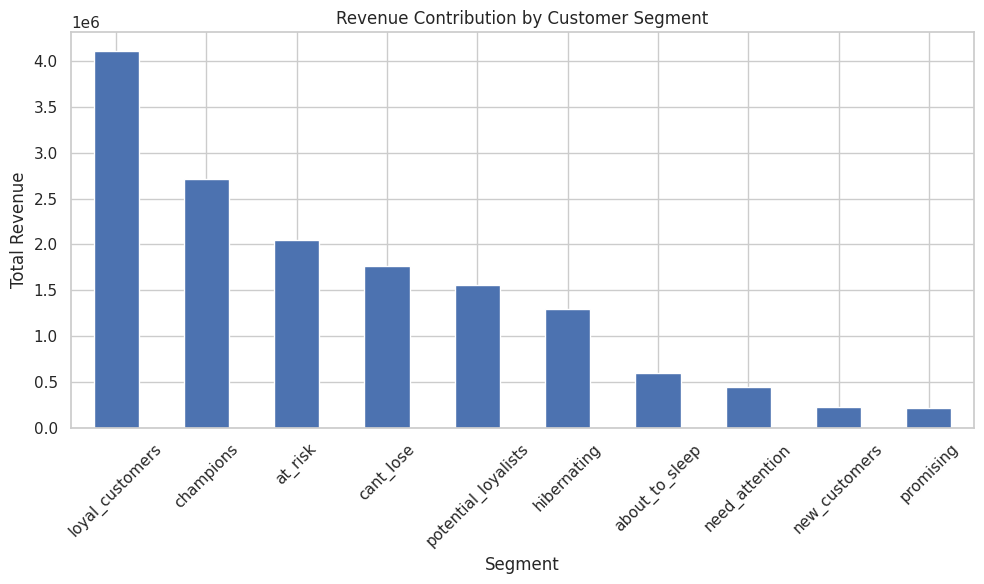

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
segment_summary["total_revenue"].plot(kind="bar")

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Key Insight

Revenue distribution shows that **loyal customers and champions contribute the largest share of total revenue**.  
However, **at-risk and cant-lose segments also represent significant revenue**, indicating potential business loss if these customers are not re-engaged.

## 🎯 Business Applications

Segment insights are translated into targeted marketing strategies.

- Premium Women's Brand Targeting: High-value segments (champions, loyal_customers) with demonstrated purchase power.
- Discount Campaign (Men & Kids): At-risk segments (cant_lose, about_to_sleep, new_customers) to prevent churn and stimulate re-engagement.

In [12]:
# ============================================================
# Premium Women's Brand Target List
# ============================================================

target_segments_a = ["champions", "loyal_customers"]

target_ids_a = rfm[rfm["segment"].isin(target_segments_a)].index

cust_ids_a = (
    df[
        df["master_id"].isin(target_ids_a) &
        df["interested_in_categories_12"].str.contains("KADIN", na=False)
    ]["master_id"]
    .drop_duplicates()
)

cust_ids_a.to_csv("premium_women_brand_target_ids.csv", index=False)
cust_ids_a.shape

(2487,)

In [13]:
# ============================================================
# Discount Campaign Target List (Men & Kids)
# ============================================================

target_segments_b = ["cant_lose", "about_to_sleep", "new_customers"]

target_ids_b = rfm[rfm["segment"].isin(target_segments_b)].index

mask_b = (
    df["interested_in_categories_12"].str.contains("ERKEK", na=False) |
    df["interested_in_categories_12"].str.contains("COCUK", na=False)
)

cust_ids_b = (
    df[df["master_id"].isin(target_ids_b) & mask_b]["master_id"]
    .drop_duplicates()
)

cust_ids_b.to_csv("men_kids_discount_target_ids.csv", index=False)
cust_ids_b.shape

(1761,)

###  Campaign Target Size

- Premium Women's Brand: **2,487 customers**
- Men & Kids Discount Campaign: **1,761 customers**

In [14]:
total_customers = rfm.shape[0]

premium_ratio = len(cust_ids_a) / total_customers * 100
discount_ratio = len(cust_ids_b) / total_customers * 100

round(premium_ratio, 2), round(discount_ratio, 2)

(12.47, 8.83)

### Campaign Reach Analysis

The **Premium Women's Brand campaign** targets **12.47% of the total customer base**, focusing on high-value segments such as champions and loyal customers.

The **Men & Kids Discount campaign** targets **8.83% of customers**, primarily from segments with churn risk.

These ratios indicate a **focused and strategic targeting approach rather than mass promotion**.  
The premium campaign concentrates on maximizing value from the most profitable customers, while the discount campaign aims to **re-engage customers who may be at risk of churn**.

## 🚀 Conclusion

RFM segmentation provides a structured framework for quantifying customer behavior and identifying value concentration across the customer base.

The analysis reveals that a relatively small group of **high-value segments (champions and loyal customers)** drives a significant portion of total revenue. At the same time, segments such as **cant_lose and at_risk** highlight important re-engagement opportunities.

By translating these insights into targeted marketing actions, businesses can improve **customer retention, reactivation, and overall marketing efficiency**.